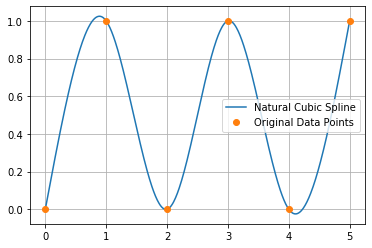

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  
    
    # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector
    
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i - 1]             # Subdiagonal
        B[i - 1] = 2 * (h[i - 1] + h[i])# Main diagonal
        C[i - 1] = h[i]                 # Superdiagonal
        D[i - 1] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1]) # Right-hand side vector
                        
    return A, B, C, D, h
                        
def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)

    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x
                   
def compute_second_derivative(x,y):
    n = len(x)
    
    A,B,C,D,h = setup_tridiagonal_matrix(x,y)
    
    M_interior = thomas_algorithm(A, B, C, D)
                        
    M = np.zeros(n)
    M[1:-1] = M_interior
                        
    return M, h

def evaluate_spline(x, y, M, xeval):
    """M: second derivatives; M[0]=M[-1]=0 for natural spline"""
    n = len(x)
    h = np.diff(x) # step sizes
                        
    i = np.searchsorted(x, xeval, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
                        
    hi = h[i]
    dx_left = xeval - x[i] # (x - xᵢ)
    dx_right = x[i+1] - xeval # (xᵢ₊₁ - x)
                        
    yeval = (
        (M[i] / (6*hi)) * dx_right**3 + # Term 1
        (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
        (y[i] /hi - M[i] *hi/6) * dx_right + # Term 3
        (y[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return yeval

x = np.array([0,1,2,3,4,5])
y = np.array([0,1,0,1,0,1])

M, h = compute_second_derivative(x,y)

xeval = np.arange(x[0], x[-1] + 0.01, 0.01)
yeval = evaluate_spline(x, y, M, xeval)

plt.plot(xeval, yeval, label='Natural Cubic Spline')
plt.plot(x, y, 'o', label='Original Data Points')
plt.grid(True)
plt.legend()
plt.show()